In [2]:
#importations outils
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#import des fichier csv contenu dans le dossier caractéristiques2005-2024
dossier = Path(r"C:\Users\nawel\Documents\projet accident de la route\datagouv\caractéristiques2005_2024")
import csv
# création d'une fonction de detection automatique des séparations
def detect_sep(fichier):
    with open(fichier, "r", encoding="latin-1") as f:
        sample = f.read(2048)
        return csv.Sniffer().sniff(sample).delimiter
dfs = []

for f in dossier.glob("*.csv"):
    sep = detect_sep(f)
    df_tmp = pd.read_csv(
        f,
        sep=sep,
        encoding="latin-1",
        low_memory=False
    )
    dfs.append(df_tmp)
#fusionne les fichier extrait  en un seul df
df_caract_2005_2024 = pd.concat(dfs, ignore_index=True)

#export du DataFrame creer
df_caract_2005_2024.to_csv("df_caract_2005_2024.csv", index=False)
df_caract_2005_2024.head()
df_caract_2005_2024.info()
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286097 entries, 0 to 1286096
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Num_Acc      1230795 non-null  float64
 1   an           1286097 non-null  int64  
 2   mois         1286097 non-null  int64  
 3   jour         1286097 non-null  int64  
 4   hrmn         1286097 non-null  object 
 5   lum          1286097 non-null  int64  
 6   agg          1286097 non-null  int64  
 7   int          1286097 non-null  int64  
 8   atm          1286024 non-null  float64
 9   col          1286078 non-null  float64
 10  com          1286095 non-null  object 
 11  adr          1137889 non-null  object 
 12  gps          480052 non-null   object 
 13  lat          799029 non-null   object 
 14  long         799025 non-null   object 
 15  dep          1286097 non-null  object 
 16  Accident_Id  55302 non-null    float64
dtypes: float64(4), int64(6), object(7)
memory usag

In [4]:
#data cleaning caractéristiques

 #Observations et rectifications:

# la colonnes ans contient des 5 alors qu'elle ne devrait avoir que des 2024 à 2005 
# Il doit il y avoir plusieurs format de date en AAAA et AA et A
# On homogeinise les formats de date de la colonne ans 

df_caract_2005_2024.loc[df_caract_2005_2024['an'] < 24, 'an'] = df_caract_2005_2024.loc[df_caract_2005_2024['an'] < 24, 'an'] + 2000

#De meme pour les HHMM et HH:MM de la colonne heure
s = df_caract_2005_2024['hrmn'].astype('string').str.strip()

# convertir HHMM -> HH:MM (1 ou 2 chiffres d’heure + 2 chiffres de minute)
s = s.str.replace(r'^(\d{1,2})(\d{2})$', r'\1:\2', regex=True)

# enregistrer
df_caract_2005_2024['hrmn'] = s


# -la colonne num_acc à un e+11  il y a un .0 a la fin de chaque numero
# on transforme en nombre entier num acc
df_caract_2005_2024['Num_Acc'] = df_caract_2005_2024['Num_Acc'].astype('Int64')
# ainsi que les colonnes long et lat pour les coordonées gps

cols_int = ['atm','col','com','long','lat']
df_caract_2005_2024[cols_int] = df_caract_2005_2024[cols_int].apply(
    lambda s: pd.to_numeric(s, errors='coerce').astype('Int64')
)
#Il y a des incoherences sur les departement.Par exemple le departement 59  est ecrit 590
df_caract_2005_2024['dep'] = df_caract_2005_2024['dep'].astype('string').str.strip()

#enlever le zéro final uniquement si longueur = 3 et finit par 0
mask = (df_caract_2005_2024['dep'].str.len() == 3) & (df_caract_2005_2024['dep'].str.endswith('0'))
df_caract_2005_2024.loc[mask, 'dep'] = df_caract_2005_2024.loc[mask, 'dep'].str[:-1]
#ajouter le zéro avant si un c'est chiffre seul
df_caract_2005_2024['dep'] = df_caract_2005_2024['dep'].apply(lambda x: x.zfill(2) if x.isdigit() and len(x) == 1 else x)

#complete la colonne gps avec la bonne lettre en fonction de dep
# Antilles
df_caract_2005_2024.loc[df_caract_2005_2024['dep'].isin(['971', '972']), 'gps'] = 'A'
# Guyane
df_caract_2005_2024.loc[df_caract_2005_2024['dep'] == '973', 'gps'] = 'G'
# Réunion
df_caract_2005_2024.loc[df_caract_2005_2024['dep'] == '974', 'gps'] = 'R'
# Mayotte
df_caract_2005_2024.loc[df_caract_2005_2024['dep'] == '976', 'gps'] = 'Y'
# Métropole (tout le reste )
df_caract_2005_2024.loc[
    df_caract_2005_2024['dep'].isin(['2A', '2B']) |
    (df_caract_2005_2024['dep'].str.isdigit() & (df_caract_2005_2024['dep'].astype(str).str.len() == 2)),
    'gps'
] = 'M'

#identifier les colonnes qui peuvent etre utile:
#num acc(essentiel),atm,lum ,dept

#supprimer les colonnes inutiles adr(pas exploitable trop de texte et on a deja l'info du lieu dans coordonée gps
#et accident_id (colonne vide)
df_caract_2005_2024 = df_caract_2005_2024.drop(columns=['adr', 'Accident_Id'])

#controle de doublons 
print(df_caract_2005_2024.duplicated().sum())
#0 doublon

#gestion des valeurs manquantes

print(df_caract_2005_2024.isna().sum().sort_values(ascending=False)) 

#supression des valeurs manquantes qui concerne une clé d’identification indispenssable
df_caract_2005_2024= df_caract_2005_2024.dropna(subset=['Num_Acc'])
 
#export du DataFrame 
df_caract_2005_2024.to_csv("df_caract_2005_2024v2.csv", index=False)


13
long       817909
lat        814696
Num_Acc     55302
gps          6194
com          3356
atm            73
col            19
an              0
mois            0
jour            0
hrmn            0
lum             0
agg             0
int             0
dep             0
dtype: int64


In [5]:
#import des fichier csv contenu dans le dossier vehicules2005_2024
dossierv = Path(r"C:\Users\nawel\Documents\projet accident de la route\datagouv\vehicules2005_2024")
import csv

dfsv = []

for f in dossierv.glob("*.csv"):
    sep = detect_sep(f)
    df_tmpv = pd.read_csv(
        f,
        sep=sep,
        encoding="latin-1",
        low_memory=False
    )
    dfsv.append(df_tmpv)

df_vehicules_2005_2024 = pd.concat(dfsv, ignore_index=True)
df_vehicules_2005_2024.info()
df_vehicules_2005_2024.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2102980 entries, 0 to 2102979
Data columns (total 11 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Num_Acc      int64  
 1   senc         float64
 2   catv         int64  
 3   occutc       float64
 4   obs          float64
 5   obsm         float64
 6   choc         float64
 7   manv         float64
 8   num_veh      object 
 9   id_vehicule  object 
 10  motor        float64
dtypes: float64(7), int64(2), object(2)
memory usage: 176.5+ MB


,Num_Acc,senc,catv,occutc,obs,obsm,choc,manv,num_veh,id_vehicule,motor
0,200500000001,0.0,7,0.0,0.0,2.0,1.0,1.0,A01,NaN,NaN
1,200500000001,0.0,7,0.0,0.0,2.0,8.0,10.0,B02,NaN,NaN
2,200500000002,0.0,7,0.0,0.0,2.0,7.0,16.0,A01,NaN,NaN
3,200500000002,0.0,2,0.0,0.0,2.0,1.0,1.0,B02,NaN,NaN
4,200500000003,0.0,2,0.0,0.0,2.0,1.0,1.0,A01,NaN,NaN


In [6]:
# data cleaning vehicules

#controle de doublons 
print(df_vehicules_2005_2024.duplicated().sum())#0 doublons

#gestion des valeurs manquantes
print(df_vehicules_2005_2024.isna().sum().sort_values(ascending=False))

#supression de colonnes inutiles vide et enexploitable
df_vehicules_2005_2024 = df_vehicules_2005_2024.drop(columns=['occutc'])#Colonne vide à 95%, sans intérêt analytique

#homogeinisation des nombres en entier sur plusieurs colonnes
cols_int = [
    'catv',
    'manv',
    'choc',
    'obs',
    'obsm',
    'senc',
    'motor']
df_vehicules_2005_2024[cols_int] = df_vehicules_2005_2024[cols_int].apply(
    lambda s: pd.to_numeric(s, errors='coerce').astype('Int64')
)
#export du DataFrame 
df_vehicules_2005_2024.to_csv("df_vehicules_2005_2024.csv", index=False)

0
id_vehicule    1635811
motor          1635811
occutc          463257
obs               1006
obsm               778
manv               468
choc               397
senc               272
Num_Acc              0
catv                 0
num_veh              0
dtype: int64


In [7]:
#import des fichier csv contenu dans le dossier usagers2005_2024
dossieru = Path(r"C:\Users\nawel\Documents\projet accident de la route\datagouv\usagers2005_2024")
import csv

dfsu = []

for f in dossieru.glob("*.csv"):
    sep = detect_sep(f)
    df_tmpu = pd.read_csv(
        f,
        sep=sep,
        encoding="latin-1",
        low_memory=False
    )
    dfsu.append(df_tmpu)

df_usagers_2005_2024 = pd.concat(dfsu, ignore_index=True)

df_usagers_2005_2024.info()
df_usagers_2005_2024.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2887353 entries, 0 to 2887352
Data columns (total 17 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Num_Acc      int64  
 1   place        float64
 2   catu         int64  
 3   grav         int64  
 4   sexe         int64  
 5   trajet       float64
 6   secu         float64
 7   locp         float64
 8   actp         object 
 9   etatp        float64
 10  an_nais      float64
 11  num_veh      object 
 12  id_vehicule  object 
 13  secu1        float64
 14  secu2        float64
 15  secu3        float64
 16  id_usager    object 
dtypes: float64(9), int64(4), object(4)
memory usage: 374.5+ MB


,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh,id_vehicule,secu1,secu2,secu3,id_usager
0,200500000001,1.0,1,4,1,1.0,11.0,0.0,0,0.0,1976.0,A01,NaN,NaN,NaN,NaN,NaN
1,200500000001,1.0,1,3,2,3.0,11.0,0.0,0,0.0,1968.0,B02,NaN,NaN,NaN,NaN,NaN
2,200500000001,2.0,2,1,1,0.0,11.0,0.0,0,0.0,1964.0,B02,NaN,NaN,NaN,NaN,NaN
3,200500000001,4.0,2,1,1,0.0,31.0,0.0,0,0.0,2004.0,B02,NaN,NaN,NaN,NaN,NaN
4,200500000001,5.0,2,1,1,0.0,11.0,0.0,0,0.0,1998.0,B02,NaN,NaN,NaN,NaN,NaN


In [8]:
#data cleaning usagers
#homogeinisation des nombres en entier sur plusieurs colonnes
cols_int_usagers = [
    'catu',
    'grav',
    'an_nais',
    'trajet',
    'secu1',
    'secu2',
    'secu3',
'secu']
df_usagers_2005_2024[cols_int_usagers] = df_usagers_2005_2024[cols_int_usagers].apply(
    lambda s: pd.to_numeric(s, errors='coerce').astype('Int64'))

# je cherche a savoir pourquoi il y a autant de valeur manquante sur  secu et secu1,2 et 3 
# j'ai constaté qu"il y avait environ 70% de valeur manquante sur secu1, 2 et 3 et 30% environs sur secu
#j'ai donc voulu verifier que lorsque une valeurr est absente sur secu est ce qu'elle est presente sur une des trois autres colonnes secu1,2ou3

mask_secu_nan = df_usagers_2005_2024['secu'].isna()
print(df_usagers_2005_2024.loc[
    mask_secu_nan,
    ['secu1', 'secu2', 'secu3']
].notna().any(axis=1).value_counts())
#c'est bien le cas pour 93% des cas je de decide donc de conclure que les 4 colonnes se completes entre elles
#on n'en supprime donc aucune d'entre elles
#on reflechira peut etre ulterieurement de les fusionner en une seul colonne

# colonnes inutile qui sont à supprimer
df_usagers_2005_2024 = df_usagers_2005_2024.drop(columns=['id_usager', 'num_veh','etatp','place','actp','locp'])

#controle de doublons 
print(df_usagers_2005_2024.duplicated().sum())#2858 doublons

#on efface les doublons de ligne.
df_usagers_2005_2024 = df_usagers_2005_2024.drop_duplicates()

print(df_usagers_2005_2024.duplicated().sum())#0 doublons ils ont bien été effacées

#gestion des valeurs manquantes
print(df_usagers_2005_2024.isna().sum().sort_values(ascending=False))
#pas de valeurs manquantes qui concerne la clés d’identifications num acc
# mettre -1 à toutes les modalités inconnus categorielles et quanti apres tri(vma):
modalites_valides_usagers = {
    'catu':   [-1, 1, 2, 3, 4, 9],      # Catégorie d'usager
    'grav':   [-1, 1, 2, 3, 4],         # Gravité (variable cible)
    'sexe':   [-1, 1, 2],               # Sexe
    'trajet': [-1, 1, 2, 3, 4, 5, 9],    # Motif du déplacement
    'secu':   [0,-1, 1, 2, 3, 4, 9],       # Équipement de sécurité 
    'secu1':   [0,-1, 1, 2, 3, 4, 9],       # Équipement de sécurité 
    'secu2':   [0,-1, 1, 2, 3, 4, 9],       # Équipement de sécurité 
    'secu3':   [0,-1, 1, 2, 3, 4, 9],       # Équipement de sécurité 
    'place':  [-1, 1, 2, 3, 9],          # Place dans le véhicule 
}   

# application du nettoyage
for col, valeurs in modalites_valides_usagers .items():
    if col in df_usagers_2005_2024.columns:
        df_usagers_2005_2024[col] = df_usagers_2005_2024[col].where(
            df_usagers_2005_2024[col].isin(valeurs),
            -1
        )

#export du DataFrame 
df_usagers_2005_2024.to_csv("df_usagers_2005_2024.csv", index=False)


True     745158
False     56537
Name: count, dtype: int64
14251
0
id_vehicule    2131385
secu1          2131385
secu2          2131385
secu3          2131385
secu            798075
an_nais          13434
trajet             486
Num_Acc              0
catu                 0
grav                 0
sexe                 0
dtype: int64


In [9]:
#import des fichiers csv contenue dans le dossier lieux2005_2024
dossierl = Path(r"C:\Users\nawel\Documents\projet accident de la route\datagouv\lieux2005_2024")
import csv

dfsl = []

for f in dossierl.glob("*.csv"):
    sep = detect_sep(f)
    df_tmpl = pd.read_csv(
        f,
        sep=sep,
        encoding="latin-1",
        low_memory=False
    )
    dfsl.append(df_tmpl)

df_lieux2005_2024 = pd.concat(dfsl, ignore_index=True)

df_lieux2005_2024.info()

df_lieux2005_2024.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1317981 entries, 0 to 1317980
Data columns (total 19 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   Num_Acc  1317981 non-null  int64  
 1   catr     1317980 non-null  float64
 2   voie     1179918 non-null  object 
 3   v1       682157 non-null   float64
 4   v2       68424 non-null    object 
 5   circ     1316407 non-null  float64
 6   nbv      1315250 non-null  object 
 7   pr       842497 non-null   object 
 8   pr1      840678 non-null   object 
 9   vosp     1315220 non-null  float64
 10  prof     1316032 non-null  float64
 11  plan     1315700 non-null  float64
 12  lartpc   902831 non-null   object 
 13  larrout  1205140 non-null  object 
 14  surf     1316057 non-null  float64
 15  infra    1312573 non-null  float64
 16  situ     1313011 non-null  float64
 17  env1     953029 non-null   float64
 18  vma      359512 non-null   float64
dtypes: float64(11), int64(1), object(7)
memory

,Num_Acc,catr,voie,v1,v2,circ,nbv,pr,pr1,vosp,prof,plan,lartpc,larrout,surf,infra,situ,env1,vma
0,200500000001,3.0,41.0,0.0,B,2.0,2,1.0,430.0,0.0,1.0,1.0,0,63,1.0,0.0,1.0,0.0,NaN
1,200500000002,2.0,41.0,0.0,NaN,0.0,2,0.0,0.0,1.0,1.0,1.0,0,100,1.0,0.0,5.0,0.0,NaN
2,200500000003,2.0,41.0,0.0,NaN,0.0,0,0.0,0.0,1.0,1.0,1.0,0,0,2.0,0.0,5.0,0.0,NaN
3,200500000004,3.0,916.0,0.0,NaN,2.0,2,0.0,0.0,0.0,1.0,1.0,0,0,1.0,0.0,1.0,0.0,NaN
4,200500000005,3.0,110.0,0.0,NaN,2.0,2,24.0,630.0,0.0,1.0,3.0,0,59,2.0,0.0,3.0,0.0,NaN


In [10]:
#data cleaning lieux
# colonnes inutile à supprimer
df_lieux2005_2024 = df_lieux2005_2024.drop(columns=['v1', 'v2','voie','vosp','pr','pr1','env1'])

#supprimer les .0 et conserve les NaN
cols_int_lieux = [
    'Num_Acc',
    'vma',
    'catr',
    'plan',
    'prof',
    'nbv',
    'circ',
    'situ',
    'infra','surf']
df_lieux2005_2024[cols_int_lieux] = df_lieux2005_2024[cols_int_lieux].apply(
    lambda s: pd.to_numeric(s, errors='coerce').astype('Int64'))

#controle de doublons lignes identiques: 
print(df_lieux2005_2024.duplicated().sum())#5273 doublons
#on efface les doublons lignes identiques: 
df_lieux2005_2024 = df_lieux2005_2024.drop_duplicates()

#recontrole de doublons: 
print(df_lieux2005_2024.duplicated().sum())#0 doublons ils ont bien été effacé

#verifier la coherence des vitesses max 30<vma<130 et ne fini pas par un 0:
print(df_lieux2005_2024.loc[
        df_lieux2005_2024['vma'].notna() &
        (
            (df_lieux2005_2024['vma'] < 30) |
            (df_lieux2005_2024['vma'] > 130)
        ) &
        (df_lieux2005_2024['vma'] % 10 != 0),
        'vma'
    ]
    .value_counts())

#rectification de quelques valeurs

mask = df_lieux2005_2024['vma'].notna()

df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 900), 'vma'] = 90
df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 800), 'vma'] = 80
df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 700), 'vma'] = 70
df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 600), 'vma'] = 60
df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 500), 'vma'] = 50
df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 400), 'vma'] = 40
df_lieux2005_2024.loc[mask & (df_lieux2005_2024['vma'] >= 300), 'vma'] = 30

# mettre 50 pour les route en ville 
df_lieux2005_2024.loc[
    df_lieux2005_2024['vma'].notna() &
    (df_lieux2005_2024['vma'] == 5) &
    (df_lieux2005_2024['catr'].isin([4, 7])),
    'vma'
] = 50


#reverifier la coherence des vitesses 
print(df_lieux2005_2024.loc[
        df_lieux2005_2024['vma'].notna() &
        (
            (df_lieux2005_2024['vma'] < 30) |
            (df_lieux2005_2024['vma'] > 130)
        ) &
        (df_lieux2005_2024['vma'] % 10 != 0),
        'vma'
    ]
    .value_counts())

# mettre -1 à toutes les modalités inconnus categorielles et quanti apres tri(vma):
modalites_valides = {
    'vma':   [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130],
    'catr':  [-1,1, 2, 3, 4, 5, 6, 7, 9],
    'surf':  [-1,1, 2, 3, 4, 5, 6, 7, 8, 9],
    'plan':  [-1,1, 2, 3, 4],
    'prof':  [-1,1, 2, 3, 4],
    'infra': [-1,1, 2, 3, 4, 5, 6, 7, 8, 9],
    'situ':  [-1,1, 2, 3, 4, 5],
    'circ':  [-1,1, 2, 3, 4],
}

# application du nettoyage
for col, valeurs in modalites_valides.items():
    if col in df_lieux2005_2024.columns:
        df_lieux2005_2024[col] = df_lieux2005_2024[col].where(
            df_lieux2005_2024[col].isin(valeurs),
            -1
        )
#verifictaion de doublons de colonne num_acc
print(lieux[lieux.duplicated(subset="Num_Acc", keep=False)].sort_values("Num_Acc").head(10))
# On remarque que les lignes sont identiques sauf les valeurs des colonne nbv et circ varient

# Je garde les lignes dont les valeurs de  circ et nbv ont des valeurs max 
df_lieux2005_2024 = (df_lieux2005_2024.groupby("Num_Acc").agg({
        "circ": "max",
        "nbv": "max",
        "catr": "first",
        "prof": "first",
        "plan": "first",
        "lartpc": "first",
        "larrout": "first",
        "surf": "first",
        "infra": "first",
        "situ": "first",
        "vma": "first"
    })
    .reset_index()
)

#export du dataframe
df_lieux2005_2024.to_csv("df_lieux_2005_2024.csv", index=False)

# pour moi le nettoyage est terminé pour les lieux
#les colonnes importantes selon moi; num acc, vma,plan,prof,surf,

5273
0
vma
-1     11573
25       220
15       200
5        149
1         88
2         59
6         36
3         17
4          5
7          3
12         2
8          2
901        1
9          1
501        1
502        1
23         1
16         1
301        1
Name: count, dtype: Int64
vma
-1    11573
25      220
15      200
1        88
5        65
2        59
6        36
3        17
4         5
7         3
12        2
8         2
9         1
23        1
16        1
Name: count, dtype: Int64


NameError: name 'lieux' is not defined

In [12]:
#Copie sécurité des df

caract = df_caract_2005_2024.copy()
lieux = df_lieux2005_2024.copy()
vehicules = df_vehicules_2005_2024.copy()
usagers = df_usagers_2005_2024.copy()

In [13]:
#data processing

# 1)Fusion Caractéristiques + Lieux

df = caract.merge(lieux,on="Num_Acc",how="left",indicator=True)

print(df["_merge"].value_counts())
df.drop(columns="_merge", inplace=True)

# 2) Fusion avec Véhicules


df = df.merge(vehicules,on="Num_Acc",how="left",indicator=True)

print(df["_merge"].value_counts())
df.drop(columns="_merge", inplace=True)


# 3) Fusion avec Usagers


df = df.merge(
    usagers,
    on=["Num_Acc", "id_vehicule"],  # clé composite importante
    how="left",
    indicator=True
)

print(df["_merge"].value_counts())
df.drop(columns="_merge", inplace=True)


# 4)Vérification finale


print("Nombre final de lignes :", df.shape[0])
print("Nombre d'accidents uniques :", df['Num_Acc'].nunique())


_merge
both          1257406
left_only           0
right_only          0
Name: count, dtype: int64
_merge
both          2032576
left_only       67659
right_only          0
Name: count, dtype: int64
_merge
both          4560975
left_only       71652
right_only          0
Name: count, dtype: int64
Nombre final de lignes : 4632627
Nombre d'accidents uniques : 1230795


In [14]:
#Creation 1 des KPI

#1)Nombre d'accident par an
df['an'] = df['an'].astype(int)
accidents_par_an = df.groupby('an')['Num_Acc'].nunique()
print(accidents_par_an)

df = df[df['an_nais'].notna()].copy()
df['age'] = df['an'] - df['an_nais'] #creation colonne age du jour de l'accident

#2)Nombre accidents par age

tues_par_age = df[df['grav'] == 2].groupby('age').size() # Nombre de tués par age
print( tues_par_age.sort_values(ascending=False))


#3)Taux de mortalité par age 

total_par_age = df.groupby('age').size()# Total usagers par âge
taux_mortalite_age = (tues_par_age / total_par_age * 100).round(2) # Taux de mortalité par age
taux_mortalite_age = taux_mortalite_age.dropna()#supprime les NaN
print(taux_mortalite_age.sort_values(ascending=False))

#Création des tranches d'ages 
bins = [0,18,30,50,70,100]
labels = ["0–18 ans","19–30 ans","31–50 ans","51–70 ans","71 ans et +"]

df['tranche_age'] = pd.cut(df['age'], bins=bins, labels=labels)

total_tranche = df.groupby('tranche_age').size()# Total usagers par tranche d'âge

tues_tranche = df[df['grav'] == 2].groupby('tranche_age').size()# Nombre de tués partranche d'age

taux_tranche = (tues_tranche / total_tranche * 100).round(2) #Taux de mortalité par tranche d'age

kpi_tranche = pd.DataFrame({
    "Total_usagers": total_tranche,
    "Taux_mortalite": taux_tranche
})

an
2005    87026
2006    82993
2007    83850
2008    76767
2009    74409
2010    69379
2011    66974
2012    62250
2013    58397
2014    59854
2015    58654
2016    59432
2017    60701
2018    57783
2019    58840
2020    47744
2021    56518
2023    54822
2024    54402
Name: Num_Acc, dtype: int64
age
20     3137
21     3119
22     3098
19     2880
23     2779
       ... 
101       5
102       4
108       2
103       1
107       1
Length: 106, dtype: int64
age
102    21.05
101    17.24
100    15.62
98     15.45
95     14.84
       ...  
11      1.15
7       1.15
10      1.09
9       1.07
107     0.81
Length: 106, dtype: float64


C:\Users\nawel\AppData\Local\Temp\ipykernel_15096\1138445193.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_tranche = df.groupby('tranche_age').size()# Total usagers par tranche d'âge
C:\Users\nawel\AppData\Local\Temp\ipykernel_15096\1138445193.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tues_tranche = df[df['grav'] == 2].groupby('tranche_age').size()# Nombre de tués partranche d'age


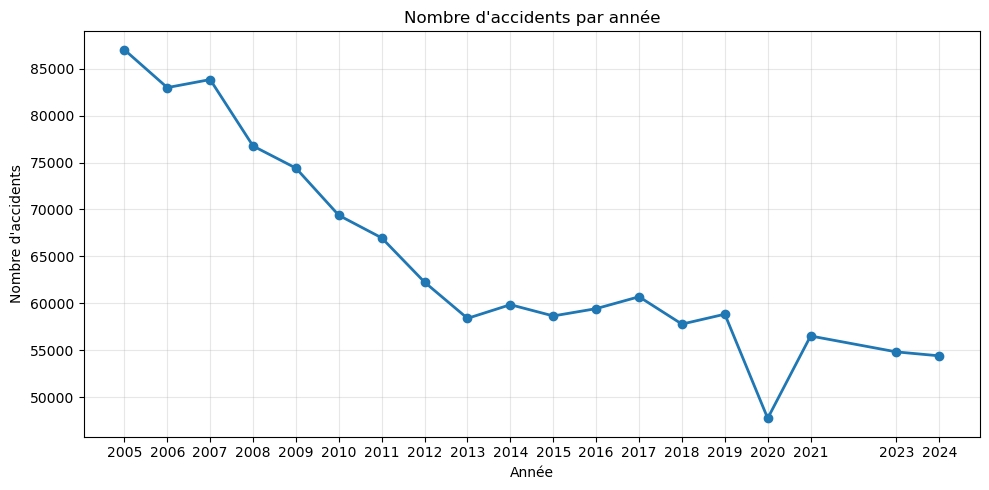

In [15]:
# 1ere visualisation associé aux KPI accident
#Nombre d'accidents par année
plt.figure(figsize=(10,5))

plt.plot(accidents_par_an.index, 
         accidents_par_an.values, 
         marker='o',
         linewidth=2)

plt.title("Nombre d'accidents par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'accidents")
plt.xticks(accidents_par_an.index)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2 eme visualisation associé aux KPI essai 3
fig, ax1 = plt.subplots(figsize=(9,5))

# Barres
ax1.bar(kpi_tranche.index, 
        kpi_tranche["Total_usagers"], 
        color="steelblue", 
        label="Nombre total d'usagers impliqués")

ax1.set_ylabel("Nombre d'usagers impliqués", color="steelblue")
ax1.set_xlabel("Tranche d'âge")

# Supprimer la notation scientifique
ax1.ticklabel_format(style='plain', axis='y')

#  Réduire l’espace vide
ax1.set_ylim(0, kpi_tranche["Total_usagers"].max()*1.1)

# Deuxième axe
ax2 = ax1.twinx()
ax2.plot(kpi_tranche.index, 
         kpi_tranche["Taux_mortalite"], 
         color="darkred", 
         marker="o",
         linewidth=2,
         label="Taux de mortalité (%)")

ax2.set_ylabel("Taux de mortalité (%)", color="darkred")
ax2.set_ylim(0, kpi_tranche["Taux_mortalite"].max()*1.2)

plt.title("Taux de mortalité et nombre d'usagers par tranche d'âge")

# Légende combinée
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

for i, txt in enumerate(kpi_tranche["Taux_mortalite"]):
    ax2.annotate(f"{txt}%", 
                 (i, kpi_tranche["Taux_mortalite"].iloc[i]),
                 textcoords="offset points",
                 xytext=(0,5),
                 ha='center')
plt.tight_layout()
plt.show()

In [ ]:
# 2 eme visualisation associé aux KPI essai 2

kpi_age = pd.DataFrame({
    "Total_usagers": total_par_age,
    "Tues": tues_par_age,
    "Taux_mortalite": taux_mortalite_age
})

kpi_age = kpi_age.fillna(0)

fig, ax1 = plt.subplots(figsize=(14,6))

# Barres → nombre d’usagers
ax1.bar(kpi_age.index, kpi_age["Total_usagers"])
ax1.set_ylabel("Nombre d'usagers")
ax1.set_xlabel("Âge")

# Deuxième axe pour le taux
ax2 = ax1.twinx()
ax2.plot(kpi_age.index, kpi_age["Taux_mortalite"])
ax2.set_ylabel("Taux de mortalité (%)")

plt.title("Taux de mortalité et nombre d'usagers par âge")
plt.show()


In [ ]:
# 2 eme visualisation associé aux KPI essai 1



#1)Nombre de personnes décédées par âge
plt.figure(figsize=(14,6))
tues_par_age.sort_index().plot(kind='bar')
plt.xticks(range(0, len(tues_par_age), 5))  # afficher 1 âge sur 5
plt.title("nombre tués par âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de tués")
plt.show()



#2)Taux de mortalité par âge
plt.figure(figsize=(14,6))
taux_mortalite_age.sort_index().plot(kind='bar')
plt.xticks(range(0, len(taux_mortalite_age), 5))  # afficher 1 âge sur 5
plt.title("taux de mortalité par âge")
plt.xlabel("Âge")
plt.ylabel("Taux de mortalité")
plt.show()

In [16]:
#mapping utiles a la visualisation

meteo_dict = {
    -1: "Non renseigné",
    1: "Normale",
    2: "Pluie légère",
    3: "Pluie forte",
    4: "Neige / grêle",
    5: "Brouillard / fumée",
    6: "Vent fort / tempête",
    7: "Temps éblouissant",
    8: "Temps couvert",
    9: "Autre"
}

df['meteo'] = df['atm'].map(meteo_dict)


lumi_dict = {
    1: "Plein jour",
    2: "Crépuscule / aube",
    3: "Nuit sans éclairage",
    4: "Nuit éclairage non allumé",
    5: "Nuit éclairage allumé"
}

df['luminosite'] = df['lum'].map(lumi_dict)

catr_dict = {
    1: "Autoroute",
    2: "Route nationale",
    3: "Route départementale",
    4: "Voie communale",
    5: "Hors réseau public",
    6: "Parc de stationnement",
    7: "Route de métropole urbaine",
    9: "Autre"
}

df['categorie_route'] = df['catr'].map(catr_dict)

In [ ]:
#Creation 2 de KPI environnementaux
accidents_meteo = (
    df.groupby('meteo')['Num_Acc']
    .nunique()
    .sort_values(ascending=False)
)

accidents_lumi = (
    df.groupby('luminosite')['Num_Acc']
    .nunique()
    .sort_values(ascending=False)
)

In [ ]:
#3eme visualisation environementeaux
#Nombre d'accidents selon les conditions météorologiques
plt.figure(figsize=(10,5))

plt.barh(accidents_meteo.index, accidents_meteo.values)

plt.title("Nombre d'accidents selon les conditions météorologiques")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Conditions météo")

plt.gca().invert_yaxis()  # plus lisible
plt.tight_layout()
plt.show()

#Nombre d'accidents selon les conditions de luminosité
plt.figure(figsize=(8,5))

plt.barh(accidents_lumi.index, accidents_lumi.values)

plt.title("Nombre d'accidents selon les conditions de luminosité")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Conditions de luminosité")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
#Creation 3 de KPI geographiques

df['dep'] = df['dep'].astype(str)
accidents_dep = (
    df.groupby('dep')['Num_Acc']
    .nunique()
    .sort_values(ascending=False)
)

# Total usagers par catégorie
total_route = df.groupby('categorie_route').size()

# Nombre de tués (grav = 2)
tues_route = df[df['grav'] == 2].groupby('categorie_route').size()

# Calcul du taux
taux_route = (tues_route / total_route) * 100

# Regroupement
kpi_route = pd.DataFrame({
    'Total_usagers': total_route,
    'Nombre_tues': tues_route,
    'Taux_mortalite (%)': taux_route
}).fillna(0)

# Tri par taux décroissant
kpi_route = kpi_route.sort_values('Taux_mortalite (%)', ascending=False)

kpi_route

,Total_usagers,Nombre_tues,Taux_mortalite (%)
categorie_route,,,
Route départementale,1483676,64863,4.371777
Route nationale,426980,14802,3.466673
Hors réseau public,5680,156,2.746479
Route de métropole urbaine,16895,358,2.118970
Autoroute,510115,8879,1.740588
Autre,65871,899,1.364789
Parc de stationnement,21847,263,1.203827
Voie communale,2019327,16024,0.793532


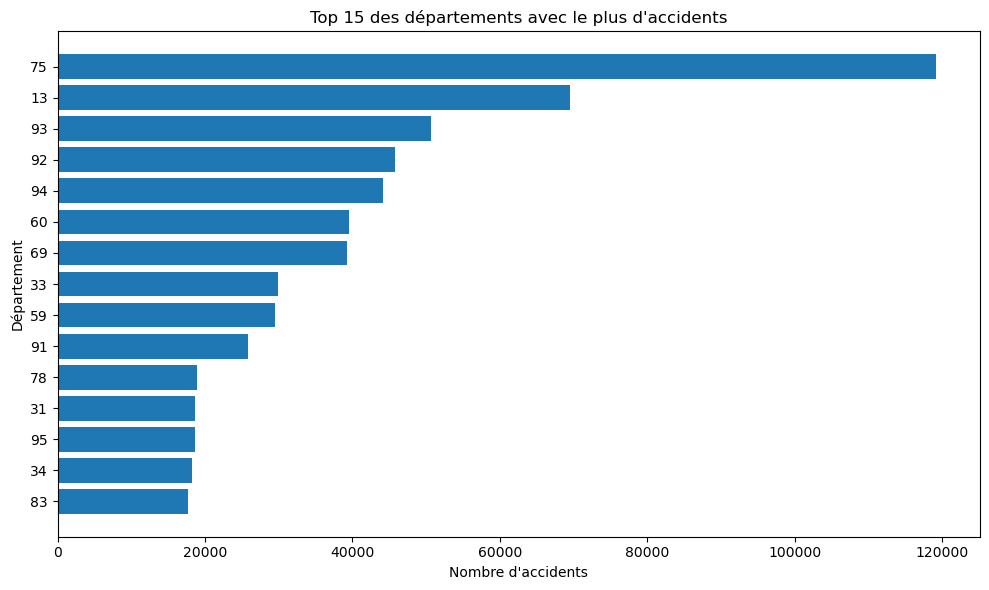

In [19]:
#4eme visualisation géographiques 
top_dep = accidents_dep.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_dep.index, top_dep.values)

plt.title("Top 15 des départements avec le plus d'accidents")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Département")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()






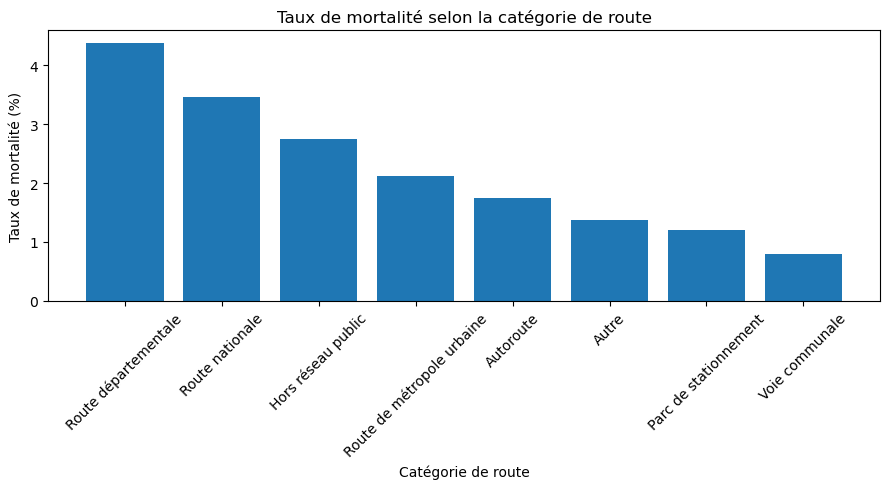

In [21]:
#5eme visualisation géographiques
plt.figure(figsize=(9,5))

plt.bar(kpi_route.index, kpi_route['Taux_mortalite (%)'])

plt.title("Taux de mortalité selon la catégorie de route")
plt.xlabel("Catégorie de route")
plt.ylabel("Taux de mortalité (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()